# Chapter 133 — Angles Between Vectors

> **Prerequisites:** ch132 (geometric dot product), ch112 (trigonometry), ch128 (norms)  
> **You will learn:**
> - How to compute the angle between vectors in any number of dimensions
> - How angles behave differently in high dimensions
> - Why measuring angles is more informative than measuring raw distance in some settings
> - Applications in data science: angular similarity, clustering, and orientation
> 
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

In 2D and 3D, the angle between two vectors is geometric and intuitive. In 100 dimensions, you cannot draw it — but the formula still works.

From ch132:
$$\theta = \arccos\left(\frac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{a}\|\|\mathbf{b}\|}\right)$$

This computes a single angle $\theta \in [0°, 180°]$ between any two nonzero vectors, regardless of dimension.

**Why angles matter beyond geometry:** In high-dimensional data, distances are unreliable because all points tend to become equidistant *(introduced in ch129)*. Angles are more stable. Two word embeddings may be far apart in L2 distance but have a small angle — meaning they represent similar concepts. Cosine similarity exploits this.

**Common misconceptions:**
- The angle formula gives $\theta \in [0, \pi]$. You cannot get a 270-degree angle between two vectors — rotation sense has no meaning here.
- Orthogonality ($\theta = 90°$) does not mean the vectors are geometrically perpendicular in any visual sense in high dimensions. It means they share no information.

## 2. Intuition & Mental Models

**Geometric:** Think of shining a flashlight (vector $\mathbf{a}$) and a second beam ($\mathbf{b}$). The angle between them is what you'd measure with a protractor at the source. In higher dimensions, you cannot visualize this, but the dot product formula gives the same measurement.

**Information-theoretic:** Two vectors at a small angle encode nearly the same directional information. Two vectors at 90° are maximally uninformative about each other. Two at 180° are perfectly opposite. The angle is a measure of *directional agreement*.

**Computational:** For machine learning, the angle formula is used to measure how similar two high-dimensional feature vectors are. `arccos(dot(a,b) / (norm(a)*norm(b)))` is a one-liner for angles in $\mathbb{R}^n$.

Recall from ch132 that cosine similarity = $\cos\theta$. The angle is simply the inverse cosine of that.

## 3. Visualization

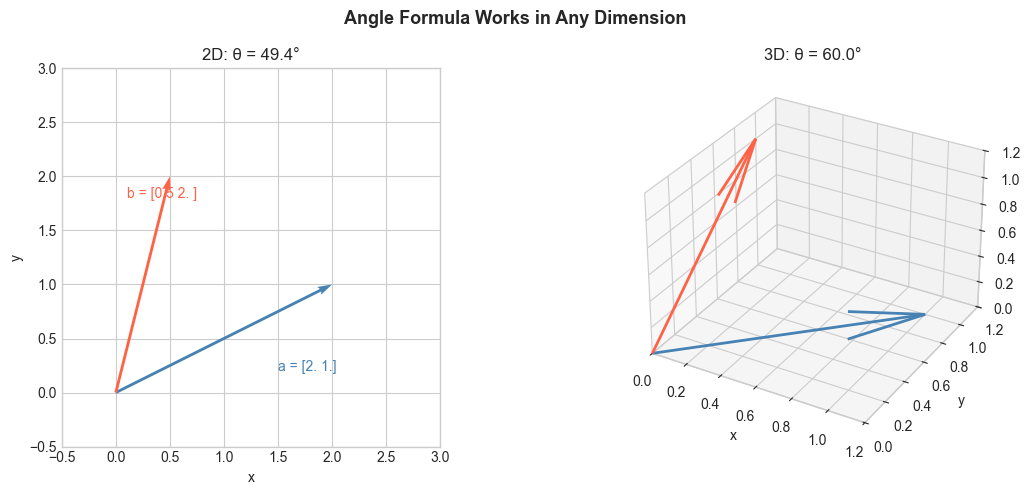

In [1]:
# --- Visualization: Angle between vectors in 2D and 3D ---

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.style.use('seaborn-v0_8-whitegrid')

def angle_between(a, b, degrees=True):
    a, b = np.asarray(a, float), np.asarray(b, float)
    cos_t = np.clip(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)), -1, 1)
    theta = np.arccos(cos_t)
    return np.degrees(theta) if degrees else theta

fig = plt.figure(figsize=(12, 5))

# 2D case
ax2 = fig.add_subplot(121)
a2 = np.array([2.0, 1.0])
b2 = np.array([0.5, 2.0])
ax2.quiver(0, 0, a2[0], a2[1], angles='xy', scale_units='xy', scale=1, color='steelblue')
ax2.quiver(0, 0, b2[0], b2[1], angles='xy', scale_units='xy', scale=1, color='tomato')
angle2d = angle_between(a2, b2)
ax2.set_xlim(-0.5, 3); ax2.set_ylim(-0.5, 3)
ax2.set_aspect('equal')
ax2.set_title(f'2D: θ = {angle2d:.1f}°')
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.text(1.5, 0.2, f'a = {a2}', color='steelblue')
ax2.text(0.1, 1.8, f'b = {b2}', color='tomato')

# 3D case
ax3 = fig.add_subplot(122, projection='3d')
a3 = np.array([1.0, 1.0, 0.0])
b3 = np.array([0.0, 1.0, 1.0])
ax3.quiver(0, 0, 0, a3[0], a3[1], a3[2], color='steelblue', linewidth=2)
ax3.quiver(0, 0, 0, b3[0], b3[1], b3[2], color='tomato',    linewidth=2)
angle3d = angle_between(a3, b3)
ax3.set_xlim(0, 1.2); ax3.set_ylim(0, 1.2); ax3.set_zlim(0, 1.2)
ax3.set_title(f'3D: θ = {angle3d:.1f}°')
ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('z')

plt.suptitle('Angle Formula Works in Any Dimension', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

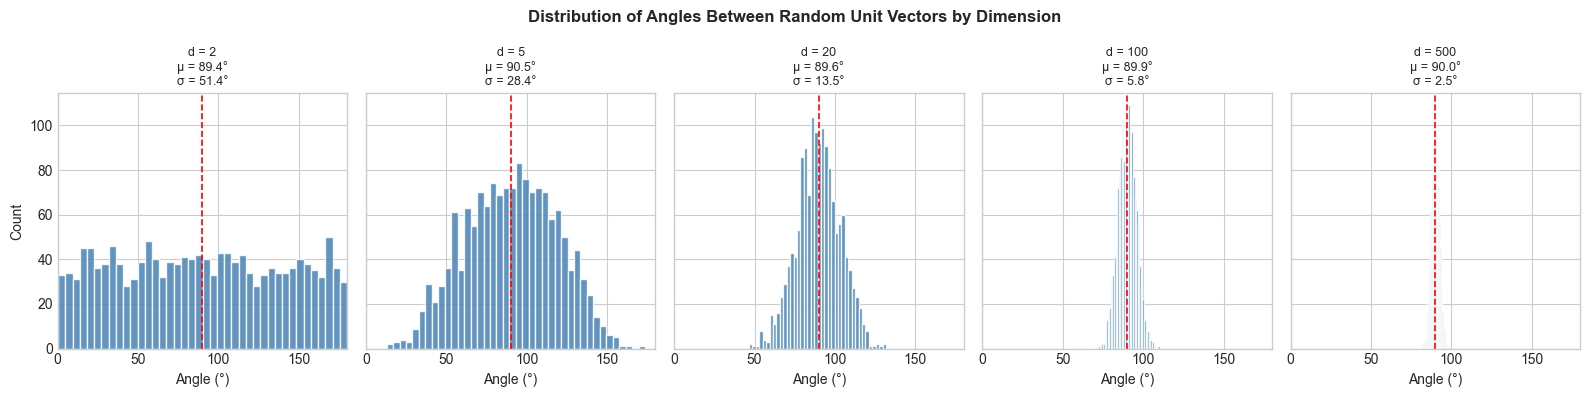

As dimension grows, angles concentrate near 90°.
Most random high-dimensional vectors are nearly orthogonal.


In [2]:
# --- Visualization: Angle distribution of random vectors in high dimensions ---
# Key phenomenon: in high dimensions, most random vectors are near-orthogonal.

N_SAMPLES = 3000
dimensions = [2, 5, 20, 100, 500]

fig, axes = plt.subplots(1, len(dimensions), figsize=(16, 4), sharey=True)

for ax, dim in zip(axes, dimensions):
    # Generate random unit vectors
    vecs = np.random.randn(N_SAMPLES, dim)
    vecs /= np.linalg.norm(vecs, axis=1, keepdims=True)

    # Compute angles between consecutive pairs
    a_batch = vecs[:N_SAMPLES//2]
    b_batch = vecs[N_SAMPLES//2:]
    dots = np.sum(a_batch * b_batch, axis=1)
    angles = np.degrees(np.arccos(np.clip(dots, -1, 1)))

    ax.hist(angles, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(90, color='red', linestyle='--', linewidth=1.2, label='90°')
    ax.set_title(f'd = {dim}\nμ = {angles.mean():.1f}°\nσ = {angles.std():.1f}°', fontsize=9)
    ax.set_xlabel('Angle (°)')
    ax.set_xlim(0, 180)

axes[0].set_ylabel('Count')
plt.suptitle('Distribution of Angles Between Random Unit Vectors by Dimension',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("As dimension grows, angles concentrate near 90°.")
print("Most random high-dimensional vectors are nearly orthogonal.")

## 4. Mathematical Formulation

**The angle formula** (from ch132):

$$\theta(\mathbf{a}, \mathbf{b}) = \arccos\!\left(\frac{\mathbf{a}\cdot\mathbf{b}}{\|\mathbf{a}\|\cdot\|\mathbf{b}\|}\right) \in [0, \pi]$$

**Key angle values and what they mean:**

| $\theta$ | $\cos\theta$ | Interpretation |
|---|---|---|
| $0°$ | $1$ | Identical direction |
| $0° < \theta < 90°$ | $(0, 1)$ | Partially aligned |
| $90°$ | $0$ | Orthogonal (no alignment) |
| $90° < \theta < 180°$ | $(-1, 0)$ | Partially opposing |
| $180°$ | $-1$ | Exactly opposite |

**Angular distance** as a metric:
$$d_{\text{ang}}(\mathbf{a}, \mathbf{b}) = \frac{\theta(\mathbf{a}, \mathbf{b})}{\pi} \in [0, 1]$$

This is a proper distance metric on the unit sphere, satisfying: non-negativity, symmetry, and the triangle inequality.

**Standard basis angles:** The angle between standard basis vector $\mathbf{e}_i = [0,\ldots,1,\ldots,0]$ and any vector $\mathbf{v}$ is:
$$\cos\theta_i = \frac{v_i}{\|\mathbf{v}\|}$$

These are called the **direction cosines** of $\mathbf{v}$. They satisfy: $\sum_i \cos^2\theta_i = 1$.

## 5. Python Implementation

In [3]:
# --- Implementation: Angles, direction cosines, angular distance ---

def angle_between(a, b, degrees=True):
    """
    Angle between two non-zero vectors in any dimension.

    Args:
        a, b:    array-like, shape (n,)
        degrees: if True, return degrees; else radians

    Returns:
        float in [0, 180] degrees or [0, π] radians
    """
    a, b = np.asarray(a, float), np.asarray(b, float)
    cos_theta = np.clip(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)), -1.0, 1.0)
    theta = np.arccos(cos_theta)
    return np.degrees(theta) if degrees else theta


def direction_cosines(v):
    """
    Direction cosines: angles that v makes with each standard basis vector.

    Args:
        v: array-like, shape (n,)

    Returns:
        angles_deg: array (n,), angles in degrees with each axis
    """
    v = np.asarray(v, float)
    v_hat = v / np.linalg.norm(v)
    cos_angles = v_hat  # cos(theta_i) = v_i / ||v||, which equals v_hat_i
    return np.degrees(np.arccos(np.clip(cos_angles, -1, 1)))


def angular_distance(a, b):
    """
    Normalized angular distance in [0, 1].
    0 = identical direction, 1 = opposite direction.

    Args:
        a, b: array-like, shape (n,)

    Returns:
        float in [0, 1]
    """
    return angle_between(a, b, degrees=False) / np.pi


# Tests
v = np.array([1.0, 1.0, 0.0])
print("Direction cosines of [1, 1, 0]:")
dc = direction_cosines(v)
for i, angle in enumerate(dc):
    print(f"  With e_{i+1}: {angle:.1f}°")
print(f"  Sum of cos²(θ_i): {np.sum(np.cos(np.radians(dc))**2):.6f}  (should be 1.0)")

print()
print(f"Angular distance [1,0] vs [0,1]:  {angular_distance([1,0],[0,1]):.3f}  (expect 0.5)")
print(f"Angular distance [1,0] vs [-1,0]: {angular_distance([1,0],[-1,0]):.3f}  (expect 1.0)")
print(f"Angular distance [1,0] vs [1,0]:  {angular_distance([1,0],[1,0]):.3f}  (expect 0.0)")

Direction cosines of [1, 1, 0]:
  With e_1: 45.0°
  With e_2: 45.0°
  With e_3: 90.0°
  Sum of cos²(θ_i): 1.000000  (should be 1.0)

Angular distance [1,0] vs [0,1]:  0.500  (expect 0.5)
Angular distance [1,0] vs [-1,0]: 1.000  (expect 1.0)
Angular distance [1,0] vs [1,0]:  0.000  (expect 0.0)


## 6. Experiments

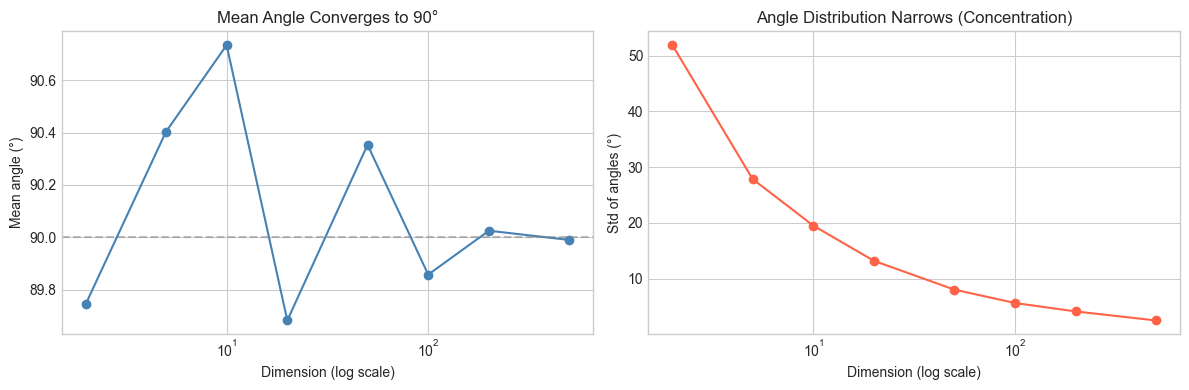

In [4]:
# --- Experiment 1: Angle concentration in high dimensions ---
# Hypothesis: as dimension increases, the std of pairwise angles shrinks.
# This means high-dimensional random vectors become "indistinguishably orthogonal".
# Try changing: N_PAIRS

N_PAIRS = 2000  # <-- modify this
dims = [2, 5, 10, 20, 50, 100, 200, 500]

mean_angles = []
std_angles  = []

for d in dims:
    a_batch = np.random.randn(N_PAIRS, d)
    b_batch = np.random.randn(N_PAIRS, d)
    a_batch /= np.linalg.norm(a_batch, axis=1, keepdims=True)
    b_batch /= np.linalg.norm(b_batch, axis=1, keepdims=True)
    dots = np.sum(a_batch * b_batch, axis=1)
    angles = np.degrees(np.arccos(np.clip(dots, -1, 1)))
    mean_angles.append(angles.mean())
    std_angles.append(angles.std())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogx(dims, mean_angles, 'o-', color='steelblue')
axes[0].axhline(90, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Dimension (log scale)'); axes[0].set_ylabel('Mean angle (°)')
axes[0].set_title('Mean Angle Converges to 90°')

axes[1].semilogx(dims, std_angles, 'o-', color='tomato')
axes[1].set_xlabel('Dimension (log scale)'); axes[1].set_ylabel('Std of angles (°)')
axes[1].set_title('Angle Distribution Narrows (Concentration)')

plt.tight_layout()
plt.show()

In [5]:
# --- Experiment 2: Angle vs L2 distance for classification ---
# Hypothesis: angle-based similarity better captures direction than L2 distance.
# Vectors of different magnitudes but same direction should be "similar".
# Try changing: SCALE

SCALE = 10.0  # <-- modify this (scales one class of vectors)

np.random.seed(42)
# Class A: vectors near [1, 0]
# Class B: vectors near [0, 1]
class_a = np.random.randn(50, 2) * 0.3 + np.array([1.0, 0.0])
class_b = np.random.randn(50, 2) * 0.3 + np.array([0.0, 1.0])

# Scale class A vectors — same direction, different magnitude
class_a_scaled = class_a * SCALE

query = np.array([0.8, 0.1])  # should be similar to class A

# L2 distances
l2_a = np.mean(np.linalg.norm(class_a_scaled - query, axis=1))
l2_b = np.mean(np.linalg.norm(class_b           - query, axis=1))

# Cosine similarities
def batch_cosine_sim(X, q):
    X_n = X / np.linalg.norm(X, axis=1, keepdims=True)
    q_n = q / np.linalg.norm(q)
    return X_n @ q_n

cos_a = np.mean(batch_cosine_sim(class_a_scaled, query))
cos_b = np.mean(batch_cosine_sim(class_b, query))

print(f"SCALE = {SCALE}")
print(f"\nL2 distance to class A (scaled): {l2_a:.2f}")
print(f"L2 distance to class B:          {l2_b:.2f}")
print(f"→ L2 says: query is closer to {'A' if l2_a < l2_b else 'B'}")
print(f"\nCosine similarity to class A: {cos_a:.4f}")
print(f"Cosine similarity to class B: {cos_b:.4f}")
print(f"→ Cosine says: query is closer to {'A' if cos_a > cos_b else 'B'}")
print("\nL2 is fooled by scale; cosine is not.")

SCALE = 10.0

L2 distance to class A (scaled): 9.27
L2 distance to class B:          1.29
→ L2 says: query is closer to B

Cosine similarity to class A: 0.9437
Cosine similarity to class B: 0.0934
→ Cosine says: query is closer to A

L2 is fooled by scale; cosine is not.


## 7. Exercises

**Easy 1.** Compute the angle between $[1, 2, 2]$ and $[2, -1, 0]$. *(Expected: 90° — verify they are orthogonal via dot product)*

**Easy 2.** What is the angle between any vector and its own negative? What does this mean geometrically? *(Expected: 180°)*

**Medium 1.** Write a function `all_angles(V)` that takes an $n \times d$ matrix of unit vectors and returns the full $n \times n$ angle matrix (in degrees). Use vectorized operations — no Python loops. *(Hint: the dot product matrix is `V @ V.T`, then `arccos`)*

**Medium 2.** Plot the angle between $[1, 0]$ and a vector that rotates from $[1, 0]$ to $[-1, 0]$ in 1000 steps. Compare this to the cosine similarity over the same path. Which is more linear in the rotation angle? *(This matters for interpolation — see ch105 Interpolation and Splines)*

**Hard.** In dimension $d$, the expected angle between two random unit vectors is exactly $90°$ for all $d \geq 2$. But the variance shrinks as $d$ grows. Derive an approximation for the standard deviation of pairwise angles as a function of $d$. Verify numerically. *(Challenge: use the central limit theorem — the dot product is a sum of $d$ i.i.d. terms)*

## 8. Mini Project — Angular Clustering

In [ ]:
# --- Mini Project: Angular Nearest-Neighbor Classifier ---
# Problem: Classify 2D data points using angular distance to class centroids.
# Unlike Euclidean k-nearest-neighbors, this classifier is scale-invariant.
# Dataset: Three classes of direction-based clusters in 2D.
# Task: Implement angular_classify and compare accuracy to L2 classification.

np.random.seed(0)

# Three direction-based classes (different magnitudes, similar directions)
class_directions = [np.array([1.0, 0.0]),
                     np.array([0.0, 1.0]),
                     np.array([-1.0, -1.0]) / np.sqrt(2)]
class_labels = ['East', 'North', 'Southwest']

# Generate points: each class has different magnitudes (noise in scale)
X_train = []
y_train = []
for label, direction in enumerate(class_directions):
    magnitudes = np.random.uniform(0.5, 5.0, 30)  # variable magnitude
    noise = np.random.randn(30, 2) * 0.15          # small angle noise
    points = magnitudes[:, None] * direction + noise
    X_train.extend(points)
    y_train.extend([label] * 30)

X_train = np.array(X_train)
y_train = np.array(y_train)

# Compute class centroids
centroids = np.array([X_train[y_train == c].mean(axis=0) for c in range(3)])

def angular_classify(X, centroids):
    """
    Classify each point in X by finding the centroid with smallest angular distance.

    Args:
        X:         array (n, d) — points to classify
        centroids: array (k, d) — class centroids

    Returns:
        labels: array (n,), predicted class indices
    """
    # TODO: normalize X and centroids
    # TODO: compute cosine similarity matrix (n x k)
    # TODO: return argmax of similarity for each point
    pass

def l2_classify(X, centroids):
    """
    Classify each point by L2 distance to centroids.
    """
    # TODO: compute distance from each point to each centroid, return argmin
    pass

# --- Evaluate (uncomment after implementing) ---
# pred_angular = angular_classify(X_train, centroids)
# pred_l2      = l2_classify(X_train, centroids)
# acc_angular  = np.mean(pred_angular == y_train)
# acc_l2       = np.mean(pred_l2      == y_train)
# print(f"Angular classifier accuracy: {acc_angular:.2%}")
# print(f"L2 classifier accuracy:      {acc_l2:.2%}")

# --- Visualize ---
# Plot X_train colored by true class, with class centroids marked.
# Visually verify that angle-based separation is clean despite magnitude variation.

## 9. Chapter Summary & Connections

- The angle $\theta = \arccos(\mathbf{a}\cdot\mathbf{b} / \|\mathbf{a}\|\|\mathbf{b}\|)$ works in any dimension.
- In high dimensions, random vectors concentrate near $\theta = 90°$ — most pairs become nearly orthogonal.
- Angle-based similarity is scale-invariant; L2 distance is not. This makes angles preferable for directional comparisons.
- Direction cosines decompose a vector into its angular relationships with each axis.

**Forward connections:**
- This reappears in **ch134 — Projections**, where the angle formula gives the length of the shadow: $\|\mathbf{b}\|\cos\theta$.
- This reappears in **ch135 — Orthogonality**, which formalizes what $\theta = 90°$ means structurally.
- This reappears in **ch183 — PCA Intuition**, where orthogonal directions of maximum variance are found.

**Backward connection:**
- This applies the derivation from **ch132 — Geometric Meaning of Dot Product**, which proved $\mathbf{a}\cdot\mathbf{b} = \|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$.

**Going deeper:** The angle formula on the unit sphere defines the **geodesic distance** on $S^{n-1}$. Spherical geometry and spherical harmonics build on this foundation.